In [1]:
import pandas as pd
from flaml import AutoML
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import shap
import matplotlib.pyplot as plt
import re
import json

### Hurricane

In [2]:
# Load your hurricane regression data
data_path = "F:/LongMig2025/data/"
df = pd.read_csv(data_path+"Regression/Hurricane_Regression_data.csv")  # Adjust path if needed

In [3]:
# Prepare features and target
X = df.drop(columns=["Unnamed: 0", "FIPS", "NMR"])
y = df["NMR"]

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and run FLAML
automl = AutoML()
automl.fit(
    X_train=X_train,
    y_train=y_train,
    task="regression",
    time_budget=600,
    metric="rmse",
    estimator_list=[
        "xgboost", "xgb_limitdepth", "rf", "extra_tree", "lgbm", "histgb", "catboost"
    ],
    log_type="all",
    log_file_name=data_path + "Regression/flaml_log.txt"    
)

[flaml.automl.logger: 05-20 02:26:30] {1728} INFO - task = regression
[flaml.automl.logger: 05-20 02:26:30] {1739} INFO - Evaluation method: cv
[flaml.automl.logger: 05-20 02:26:30] {1838} INFO - Minimizing error metric: rmse
[flaml.automl.logger: 05-20 02:26:30] {1955} INFO - List of ML learners in AutoML Run: ['xgboost', 'xgb_limitdepth', 'rf', 'extra_tree', 'lgbm', 'histgb', 'catboost']
[flaml.automl.logger: 05-20 02:26:30] {2258} INFO - iteration 0, current learner xgboost
[flaml.automl.logger: 05-20 02:26:30] {2393} INFO - Estimated sufficient time budget=3376s. Estimated necessary time budget=18s.
[flaml.automl.logger: 05-20 02:26:30] {2442} INFO -  at 0.4s,	estimator xgboost's best error=8.8882,	best estimator xgboost's best error=8.8882
[flaml.automl.logger: 05-20 02:26:30] {2258} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 05-20 02:26:30] {2442} INFO -  at 0.6s,	estimator lgbm's best error=8.8714,	best estimator lgbm's best error=8.8714
[flaml.automl.logger:

[flaml.automl.logger: 05-20 02:26:39] {2258} INFO - iteration 34, current learner histgb
[flaml.automl.logger: 05-20 02:26:39] {2442} INFO -  at 9.7s,	estimator histgb's best error=6.0070,	best estimator histgb's best error=6.0070
[flaml.automl.logger: 05-20 02:26:39] {2258} INFO - iteration 35, current learner xgboost
[flaml.automl.logger: 05-20 02:26:40] {2442} INFO -  at 10.2s,	estimator xgboost's best error=6.7220,	best estimator histgb's best error=6.0070
[flaml.automl.logger: 05-20 02:26:40] {2258} INFO - iteration 36, current learner histgb
[flaml.automl.logger: 05-20 02:26:40] {2442} INFO -  at 10.3s,	estimator histgb's best error=6.0070,	best estimator histgb's best error=6.0070
[flaml.automl.logger: 05-20 02:26:40] {2258} INFO - iteration 37, current learner histgb
[flaml.automl.logger: 05-20 02:26:40] {2442} INFO -  at 10.5s,	estimator histgb's best error=6.0070,	best estimator histgb's best error=6.0070
[flaml.automl.logger: 05-20 02:26:40] {2258} INFO - iteration 38, curre

[flaml.automl.logger: 05-20 02:26:53] {2258} INFO - iteration 70, current learner histgb
[flaml.automl.logger: 05-20 02:26:53] {2442} INFO -  at 23.4s,	estimator histgb's best error=5.8415,	best estimator histgb's best error=5.8415
[flaml.automl.logger: 05-20 02:26:53] {2258} INFO - iteration 71, current learner histgb
[flaml.automl.logger: 05-20 02:26:53] {2442} INFO -  at 23.5s,	estimator histgb's best error=5.8415,	best estimator histgb's best error=5.8415
[flaml.automl.logger: 05-20 02:26:53] {2258} INFO - iteration 72, current learner lgbm
[flaml.automl.logger: 05-20 02:26:54] {2442} INFO -  at 24.1s,	estimator lgbm's best error=6.0438,	best estimator histgb's best error=5.8415
[flaml.automl.logger: 05-20 02:26:54] {2258} INFO - iteration 73, current learner histgb
[flaml.automl.logger: 05-20 02:26:54] {2442} INFO -  at 24.2s,	estimator histgb's best error=5.8415,	best estimator histgb's best error=5.8415
[flaml.automl.logger: 05-20 02:26:54] {2258} INFO - iteration 74, current le

[flaml.automl.logger: 05-20 02:27:33] {2442} INFO -  at 63.3s,	estimator histgb's best error=5.8415,	best estimator histgb's best error=5.8415
[flaml.automl.logger: 05-20 02:27:33] {2258} INFO - iteration 106, current learner extra_tree
[flaml.automl.logger: 05-20 02:27:34] {2442} INFO -  at 64.0s,	estimator extra_tree's best error=6.8690,	best estimator histgb's best error=5.8415
[flaml.automl.logger: 05-20 02:27:34] {2258} INFO - iteration 107, current learner histgb
[flaml.automl.logger: 05-20 02:27:34] {2442} INFO -  at 64.2s,	estimator histgb's best error=5.8415,	best estimator histgb's best error=5.8415
[flaml.automl.logger: 05-20 02:27:34] {2258} INFO - iteration 108, current learner histgb
[flaml.automl.logger: 05-20 02:27:34] {2442} INFO -  at 64.4s,	estimator histgb's best error=5.8415,	best estimator histgb's best error=5.8415
[flaml.automl.logger: 05-20 02:27:34] {2258} INFO - iteration 109, current learner extra_tree
[flaml.automl.logger: 05-20 02:27:35] {2442} INFO -  at 

[flaml.automl.logger: 05-20 02:28:59] {2442} INFO -  at 149.3s,	estimator histgb's best error=5.8415,	best estimator histgb's best error=5.8415
[flaml.automl.logger: 05-20 02:28:59] {2258} INFO - iteration 141, current learner rf
[flaml.automl.logger: 05-20 02:29:00] {2442} INFO -  at 150.2s,	estimator rf's best error=6.3275,	best estimator histgb's best error=5.8415
[flaml.automl.logger: 05-20 02:29:00] {2258} INFO - iteration 142, current learner histgb
[flaml.automl.logger: 05-20 02:29:00] {2442} INFO -  at 150.5s,	estimator histgb's best error=5.8415,	best estimator histgb's best error=5.8415
[flaml.automl.logger: 05-20 02:29:00] {2258} INFO - iteration 143, current learner extra_tree
[flaml.automl.logger: 05-20 02:29:01] {2442} INFO -  at 151.0s,	estimator extra_tree's best error=6.3108,	best estimator histgb's best error=5.8415
[flaml.automl.logger: 05-20 02:29:01] {2258} INFO - iteration 144, current learner histgb
[flaml.automl.logger: 05-20 02:29:01] {2442} INFO -  at 151.2s,	

...

[flaml.automl.logger: 05-20 02:31:36] {2258} INFO - iteration 211, current learner histgb
[flaml.automl.logger: 05-20 02:31:36] {2442} INFO -  at 306.6s,	estimator histgb's best error=5.6511,	best estimator histgb's best error=5.6511
[flaml.automl.logger: 05-20 02:31:36] {2258} INFO - iteration 212, current learner histgb
[flaml.automl.logger: 05-20 02:31:37] {2442} INFO -  at 307.0s,	estimator histgb's best error=5.6511,	best estimator histgb's best error=5.6511
[flaml.automl.logger: 05-20 02:31:37] {2258} INFO - iteration 213, current learner histgb
[flaml.automl.logger: 05-20 02:31:37] {2442} INFO -  at 307.3s,	estimator histgb's best error=5.6511,	best estimator histgb's best error=5.6511
[flaml.automl.logger: 05-20 02:31:37] {2258} INFO - iteration 214, current learner histgb
[flaml.automl.logger: 05-20 02:31:37] {2442} INFO -  at 307.7s,	estimator histgb's best error=5.6511,	best estimator histgb's best error=5.6511
[flaml.automl.logger: 05-20 02:31:37] {2258} INFO - iteration 21

[flaml.automl.logger: 05-20 02:31:54] {2258} INFO - iteration 246, current learner histgb
[flaml.automl.logger: 05-20 02:31:54] {2442} INFO -  at 324.2s,	estimator histgb's best error=5.6511,	best estimator histgb's best error=5.6511
[flaml.automl.logger: 05-20 02:31:54] {2258} INFO - iteration 247, current learner xgb_limitdepth
[flaml.automl.logger: 05-20 02:31:55] {2442} INFO -  at 324.8s,	estimator xgb_limitdepth's best error=6.3739,	best estimator histgb's best error=5.6511
[flaml.automl.logger: 05-20 02:31:55] {2258} INFO - iteration 248, current learner histgb
[flaml.automl.logger: 05-20 02:31:55] {2442} INFO -  at 325.2s,	estimator histgb's best error=5.6511,	best estimator histgb's best error=5.6511
[flaml.automl.logger: 05-20 02:31:55] {2258} INFO - iteration 249, current learner histgb
[flaml.automl.logger: 05-20 02:31:55] {2442} INFO -  at 325.6s,	estimator histgb's best error=5.6511,	best estimator histgb's best error=5.6511
[flaml.automl.logger: 05-20 02:31:55] {2258} INF

[flaml.automl.logger: 05-20 02:33:33] {2258} INFO - iteration 281, current learner catboost
[flaml.automl.logger: 05-20 02:34:44] {2442} INFO -  at 494.2s,	estimator catboost's best error=5.8923,	best estimator histgb's best error=5.6511
[flaml.automl.logger: 05-20 02:34:44] {2258} INFO - iteration 282, current learner histgb
[flaml.automl.logger: 05-20 02:34:44] {2442} INFO -  at 494.6s,	estimator histgb's best error=5.6511,	best estimator histgb's best error=5.6511
[flaml.automl.logger: 05-20 02:34:44] {2258} INFO - iteration 283, current learner lgbm
[flaml.automl.logger: 05-20 02:34:45] {2442} INFO -  at 495.7s,	estimator lgbm's best error=6.0047,	best estimator histgb's best error=5.6511
[flaml.automl.logger: 05-20 02:34:45] {2258} INFO - iteration 284, current learner histgb
[flaml.automl.logger: 05-20 02:34:46] {2442} INFO -  at 496.3s,	estimator histgb's best error=5.6511,	best estimator histgb's best error=5.6511
[flaml.automl.logger: 05-20 02:34:46] {2258} INFO - iteration 28

[flaml.automl.logger: 05-20 02:35:34] {2258} INFO - iteration 316, current learner histgb
[flaml.automl.logger: 05-20 02:35:34] {2442} INFO -  at 544.7s,	estimator histgb's best error=5.6511,	best estimator histgb's best error=5.6511
[flaml.automl.logger: 05-20 02:35:34] {2258} INFO - iteration 317, current learner histgb
[flaml.automl.logger: 05-20 02:35:35] {2442} INFO -  at 545.0s,	estimator histgb's best error=5.6511,	best estimator histgb's best error=5.6511
[flaml.automl.logger: 05-20 02:35:35] {2258} INFO - iteration 318, current learner histgb
[flaml.automl.logger: 05-20 02:35:35] {2442} INFO -  at 545.4s,	estimator histgb's best error=5.6511,	best estimator histgb's best error=5.6511
[flaml.automl.logger: 05-20 02:35:35] {2258} INFO - iteration 319, current learner lgbm
[flaml.automl.logger: 05-20 02:35:36] {2442} INFO -  at 546.7s,	estimator lgbm's best error=6.0047,	best estimator histgb's best error=5.6511
[flaml.automl.logger: 05-20 02:35:36] {2258} INFO - iteration 320, c

[flaml.automl.logger: 05-20 02:37:23] {1986} INFO - Time taken to find the best model: 301.18094778060913


In [4]:
print("Best model:", automl.model.estimator)

Best model: HistGradientBoostingRegressor(l2_regularization=2.7595689694540195,
                              learning_rate=0.1862844381302944, max_bins=127,
                              max_iter=68, max_leaf_nodes=13,
                              min_samples_leaf=16, random_state=24092023)


In [5]:
log_path = data_path + "Regression/flaml_log.txt"  

entries = []

with open(log_path, "r") as f:
    for line in f:
        try:
            record = json.loads(line)
            learner = record.get("learner")
            val_loss = record.get("validation_loss")
            config = record.get("config")
            if learner and val_loss:
                entries.append({
                    "learner": learner,
                    "validation_loss": val_loss,
                    "config": config
                })
        except json.JSONDecodeError:
            continue

In [6]:
log_df = pd.DataFrame(entries)
log_df = log_df.sort_values("validation_loss").drop_duplicates("learner").head(10).reset_index(drop=True)
print(log_df[["learner", "validation_loss"]])


          learner  validation_loss
0          histgb         5.651062
1        catboost         5.853609
2            lgbm         6.004695
3              rf         6.017952
4      extra_tree         6.310795
5         xgboost         6.370808
6  xgb_limitdepth         6.373921


In [7]:
y_pred = automl.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
me = np.mean(y_test - y_pred)
r2 = r2_score(y_test, y_pred)
print("✅ Best Model Performance on Test Set")
print(f"Best Model: {automl.best_estimator}")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"ME (Mean Error): {me:.4f}")


✅ Best Model Performance on Test Set
Best Model: histgb
R² Score: 0.6962
RMSE: 5.3556
MAE: 3.9637
ME (Mean Error): 0.3360


PermutationExplainer explainer: 577it [01:05,  7.89it/s]                                                               


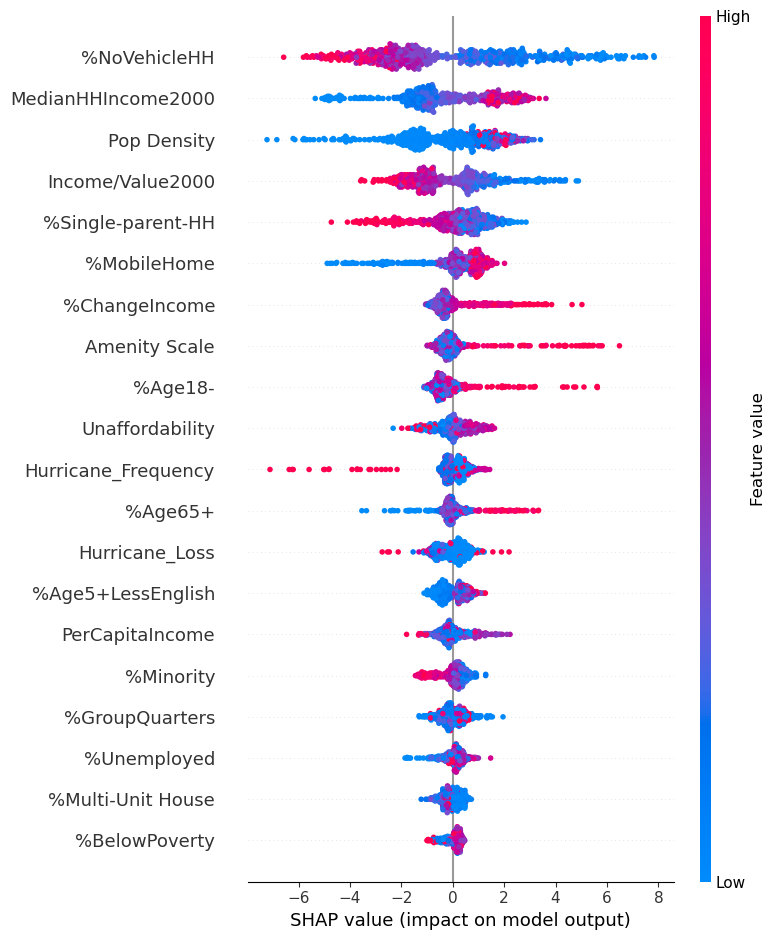

In [8]:
explainer = shap.Explainer(automl.model.predict, X_train)
shap_values = explainer(X_train)
shap.summary_plot(shap_values, X_train)

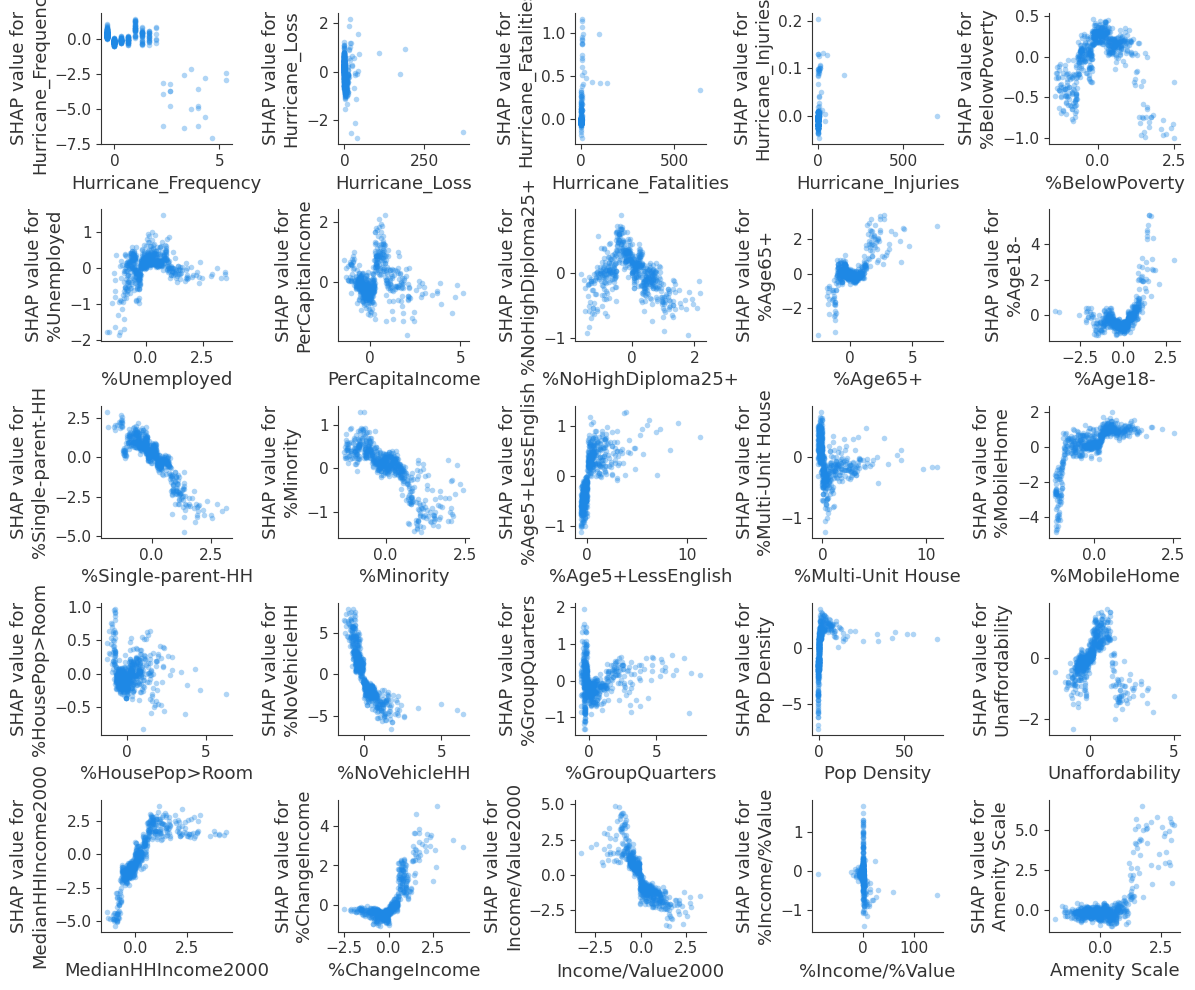

In [9]:
# Get all feature names
all_features = X_train.columns.tolist()

# Grid layout setup
num_features = len(all_features)
cols = 5
rows = (num_features + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(12,10))
axes = axes.flatten()

# Loop through each feature to create a SHAP dependence plot in its subplot
for i, feature in enumerate(all_features):
    shap.dependence_plot(
        feature,
        shap_values.values,
        X_train,
        ax=axes[i],
        interaction_index=None,  # Ensures no color gradient (blue dots only)
        show=False,
        alpha=0.35
    )
#     axes[i].set_title(f"{feature}", fontsize=10)
# Hide any unused subplot areas
for j in range(len(all_features), len(axes)):
    axes[j].axis("off")

# Final layout and output
plt.tight_layout()
plt.show()

## Flood

In [11]:
# Load your hurricane regression data
data_path = "F:/LongMig2025/data/"
df = pd.read_csv(data_path+"Regression/Flood_Regression_data.csv")  # Adjust path if needed

In [12]:
# Prepare features and target
X = df.drop(columns=["Unnamed: 0", "FIPS", "NMR"])
y = df["NMR"]

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and run FLAML
automl = AutoML()
automl.fit(
    X_train=X_train,
    y_train=y_train,
    task="regression",
    time_budget=600,
    metric="rmse",
    estimator_list=[
        "xgboost", "xgb_limitdepth", "rf", "extra_tree", "lgbm", "histgb", "catboost"
    ],
    log_type="all",
    log_file_name=data_path + "Regression/flaml_log_flood.txt"    
)

[flaml.automl.logger: 05-20 02:53:40] {1728} INFO - task = regression
[flaml.automl.logger: 05-20 02:53:40] {1739} INFO - Evaluation method: cv
[flaml.automl.logger: 05-20 02:53:40] {1838} INFO - Minimizing error metric: rmse
[flaml.automl.logger: 05-20 02:53:40] {1955} INFO - List of ML learners in AutoML Run: ['xgboost', 'xgb_limitdepth', 'rf', 'extra_tree', 'lgbm', 'histgb', 'catboost']
[flaml.automl.logger: 05-20 02:53:40] {2258} INFO - iteration 0, current learner xgboost
[flaml.automl.logger: 05-20 02:53:40] {2393} INFO - Estimated sufficient time budget=3508s. Estimated necessary time budget=19s.
[flaml.automl.logger: 05-20 02:53:40] {2442} INFO -  at 0.4s,	estimator xgboost's best error=7.3311,	best estimator xgboost's best error=7.3311
[flaml.automl.logger: 05-20 02:53:40] {2258} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 05-20 02:53:41] {2442} INFO -  at 0.6s,	estimator lgbm's best error=7.3143,	best estimator lgbm's best error=7.3143
[flaml.automl.logger:

[flaml.automl.logger: 05-20 02:53:53] {2258} INFO - iteration 34, current learner histgb
[flaml.automl.logger: 05-20 02:53:53] {2442} INFO -  at 12.9s,	estimator histgb's best error=5.0964,	best estimator histgb's best error=5.0964
[flaml.automl.logger: 05-20 02:53:53] {2258} INFO - iteration 35, current learner extra_tree
[flaml.automl.logger: 05-20 02:53:54] {2442} INFO -  at 13.6s,	estimator extra_tree's best error=5.6062,	best estimator histgb's best error=5.0964
[flaml.automl.logger: 05-20 02:53:54] {2258} INFO - iteration 36, current learner histgb
[flaml.automl.logger: 05-20 02:53:54] {2442} INFO -  at 14.5s,	estimator histgb's best error=4.9818,	best estimator histgb's best error=4.9818
[flaml.automl.logger: 05-20 02:53:54] {2258} INFO - iteration 37, current learner histgb
[flaml.automl.logger: 05-20 02:53:57] {2442} INFO -  at 16.9s,	estimator histgb's best error=4.8313,	best estimator histgb's best error=4.8313
[flaml.automl.logger: 05-20 02:53:57] {2258} INFO - iteration 38

[flaml.automl.logger: 05-20 02:54:47] {2442} INFO -  at 67.4s,	estimator xgb_limitdepth's best error=5.2507,	best estimator histgb's best error=4.8134
[flaml.automl.logger: 05-20 02:54:47] {2258} INFO - iteration 70, current learner xgb_limitdepth
[flaml.automl.logger: 05-20 02:54:48] {2442} INFO -  at 68.1s,	estimator xgb_limitdepth's best error=5.2507,	best estimator histgb's best error=4.8134
[flaml.automl.logger: 05-20 02:54:48] {2258} INFO - iteration 71, current learner xgb_limitdepth
[flaml.automl.logger: 05-20 02:54:49] {2442} INFO -  at 68.8s,	estimator xgb_limitdepth's best error=5.2507,	best estimator histgb's best error=4.8134
[flaml.automl.logger: 05-20 02:54:49] {2258} INFO - iteration 72, current learner xgb_limitdepth
[flaml.automl.logger: 05-20 02:54:49] {2442} INFO -  at 69.4s,	estimator xgb_limitdepth's best error=5.2507,	best estimator histgb's best error=4.8134
[flaml.automl.logger: 05-20 02:54:49] {2258} INFO - iteration 73, current learner xgb_limitdepth
[flaml.a

[flaml.automl.logger: 05-20 02:55:46] {2258} INFO - iteration 104, current learner extra_tree
[flaml.automl.logger: 05-20 02:55:47] {2442} INFO -  at 127.0s,	estimator extra_tree's best error=5.0029,	best estimator histgb's best error=4.8134
[flaml.automl.logger: 05-20 02:55:47] {2258} INFO - iteration 105, current learner xgboost
[flaml.automl.logger: 05-20 02:55:47] {2442} INFO -  at 127.4s,	estimator xgboost's best error=5.4818,	best estimator histgb's best error=4.8134
[flaml.automl.logger: 05-20 02:55:47] {2258} INFO - iteration 106, current learner extra_tree
[flaml.automl.logger: 05-20 02:55:49] {2442} INFO -  at 128.6s,	estimator extra_tree's best error=4.9497,	best estimator histgb's best error=4.8134
[flaml.automl.logger: 05-20 02:55:49] {2258} INFO - iteration 107, current learner extra_tree
[flaml.automl.logger: 05-20 02:55:51] {2442} INFO -  at 130.8s,	estimator extra_tree's best error=4.9497,	best estimator histgb's best error=4.8134
[flaml.automl.logger: 05-20 02:55:51] 

[flaml.automl.logger: 05-20 02:57:10] {2258} INFO - iteration 139, current learner extra_tree
[flaml.automl.logger: 05-20 02:57:12] {2442} INFO -  at 212.2s,	estimator extra_tree's best error=4.8632,	best estimator histgb's best error=4.8040
[flaml.automl.logger: 05-20 02:57:12] {2258} INFO - iteration 140, current learner xgboost
[flaml.automl.logger: 05-20 02:57:16] {2442} INFO -  at 216.2s,	estimator xgboost's best error=4.9163,	best estimator histgb's best error=4.8040
[flaml.automl.logger: 05-20 02:57:16] {2258} INFO - iteration 141, current learner extra_tree
[flaml.automl.logger: 05-20 02:57:19] {2442} INFO -  at 218.8s,	estimator extra_tree's best error=4.8632,	best estimator histgb's best error=4.8040
[flaml.automl.logger: 05-20 02:57:19] {2258} INFO - iteration 142, current learner xgboost
[flaml.automl.logger: 05-20 02:57:23] {2442} INFO -  at 223.4s,	estimator xgboost's best error=4.9163,	best estimator histgb's best error=4.8040
[flaml.automl.logger: 05-20 02:57:23] {2258}

[flaml.automl.logger: 05-20 02:59:07] {2258} INFO - iteration 174, current learner rf
[flaml.automl.logger: 05-20 02:59:09] {2442} INFO -  at 329.3s,	estimator rf's best error=4.9743,	best estimator histgb's best error=4.8040
[flaml.automl.logger: 05-20 02:59:09] {2258} INFO - iteration 175, current learner extra_tree
[flaml.automl.logger: 05-20 02:59:14] {2442} INFO -  at 334.0s,	estimator extra_tree's best error=4.8632,	best estimator histgb's best error=4.8040
[flaml.automl.logger: 05-20 02:59:14] {2258} INFO - iteration 176, current learner extra_tree
[flaml.automl.logger: 05-20 02:59:15] {2442} INFO -  at 335.3s,	estimator extra_tree's best error=4.8632,	best estimator histgb's best error=4.8040
[flaml.automl.logger: 05-20 02:59:15] {2258} INFO - iteration 177, current learner xgb_limitdepth
[flaml.automl.logger: 05-20 02:59:17] {2442} INFO -  at 336.6s,	estimator xgb_limitdepth's best error=5.0334,	best estimator histgb's best error=4.8040
[flaml.automl.logger: 05-20 02:59:17] {2

[flaml.automl.logger: 05-20 03:02:12] {2442} INFO -  at 512.0s,	estimator histgb's best error=4.7912,	best estimator histgb's best error=4.7912
[flaml.automl.logger: 05-20 03:02:12] {2258} INFO - iteration 209, current learner catboost
[flaml.automl.logger: 05-20 03:02:16] {2442} INFO -  at 515.8s,	estimator catboost's best error=4.8548,	best estimator histgb's best error=4.7912
[flaml.automl.logger: 05-20 03:02:16] {2258} INFO - iteration 210, current learner histgb
[flaml.automl.logger: 05-20 03:02:18] {2442} INFO -  at 518.3s,	estimator histgb's best error=4.7912,	best estimator histgb's best error=4.7912
[flaml.automl.logger: 05-20 03:02:18] {2258} INFO - iteration 211, current learner extra_tree
[flaml.automl.logger: 05-20 03:02:22] {2442} INFO -  at 522.4s,	estimator extra_tree's best error=4.8632,	best estimator histgb's best error=4.7912
[flaml.automl.logger: 05-20 03:02:22] {2258} INFO - iteration 212, current learner extra_tree
[flaml.automl.logger: 05-20 03:02:24] {2442} INF

In [13]:
print("Best model:", automl.model.estimator)

Best model: HistGradientBoostingRegressor(l2_regularization=5.843252112061829,
                              learning_rate=0.052375124028920826, max_iter=702,
                              max_leaf_nodes=13, min_samples_leaf=15,
                              random_state=24092023)


In [14]:
log_path = data_path + "Regression/flaml_log_flood.txt"  

entries = []

with open(log_path, "r") as f:
    for line in f:
        try:
            record = json.loads(line)
            learner = record.get("learner")
            val_loss = record.get("validation_loss")
            config = record.get("config")
            if learner and val_loss:
                entries.append({
                    "learner": learner,
                    "validation_loss": val_loss,
                    "config": config
                })
        except json.JSONDecodeError:
            continue

In [15]:
log_df = pd.DataFrame(entries)
log_df = log_df.sort_values("validation_loss").drop_duplicates("learner").head(10).reset_index(drop=True)
print(log_df[["learner", "validation_loss"]])

          learner  validation_loss
0          histgb         4.791239
1  xgb_limitdepth         4.811416
2        catboost         4.828988
3         xgboost         4.853078
4      extra_tree         4.859632
5            lgbm         4.956523
6              rf         4.974268


In [16]:
y_pred = automl.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
me = np.mean(y_test - y_pred)
r2 = r2_score(y_test, y_pred)
print("✅ Best Model Performance on Test Set")
print(f"Best Model: {automl.best_estimator}")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"ME (Mean Error): {me:.4f}")


✅ Best Model Performance on Test Set
Best Model: histgb
R² Score: 0.7010
RMSE: 4.5473
MAE: 3.2718
ME (Mean Error): 0.0935


PermutationExplainer explainer: 2216it [34:30,  1.06it/s]                                                              


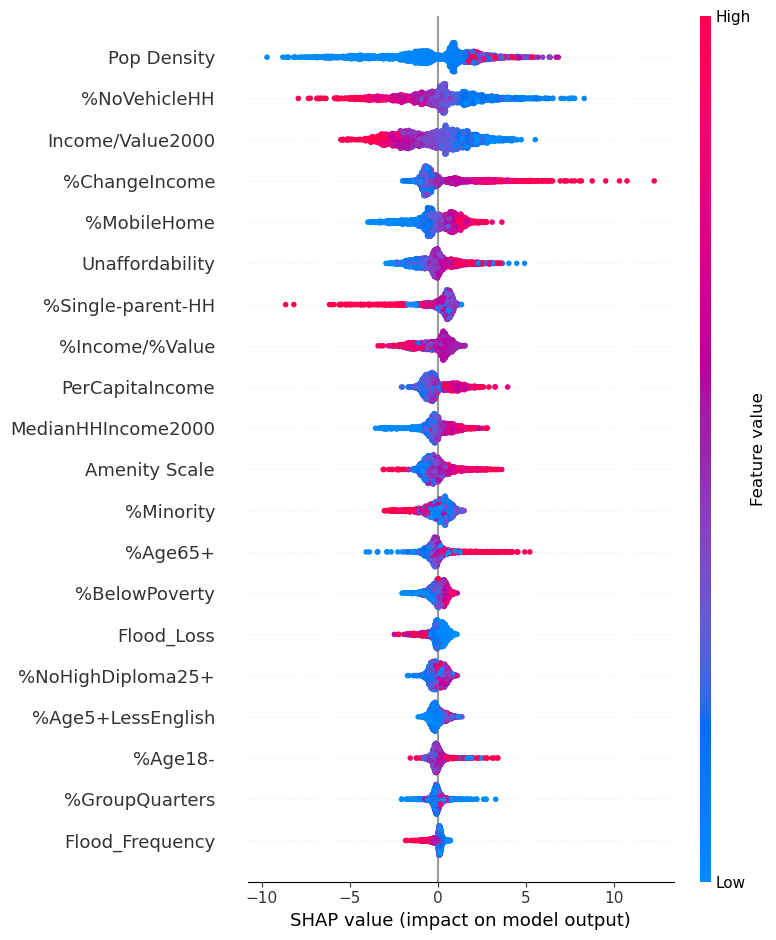

In [17]:
explainer = shap.Explainer(automl.model.predict, X_train)
shap_values = explainer(X_train)
shap.summary_plot(shap_values, X_train)

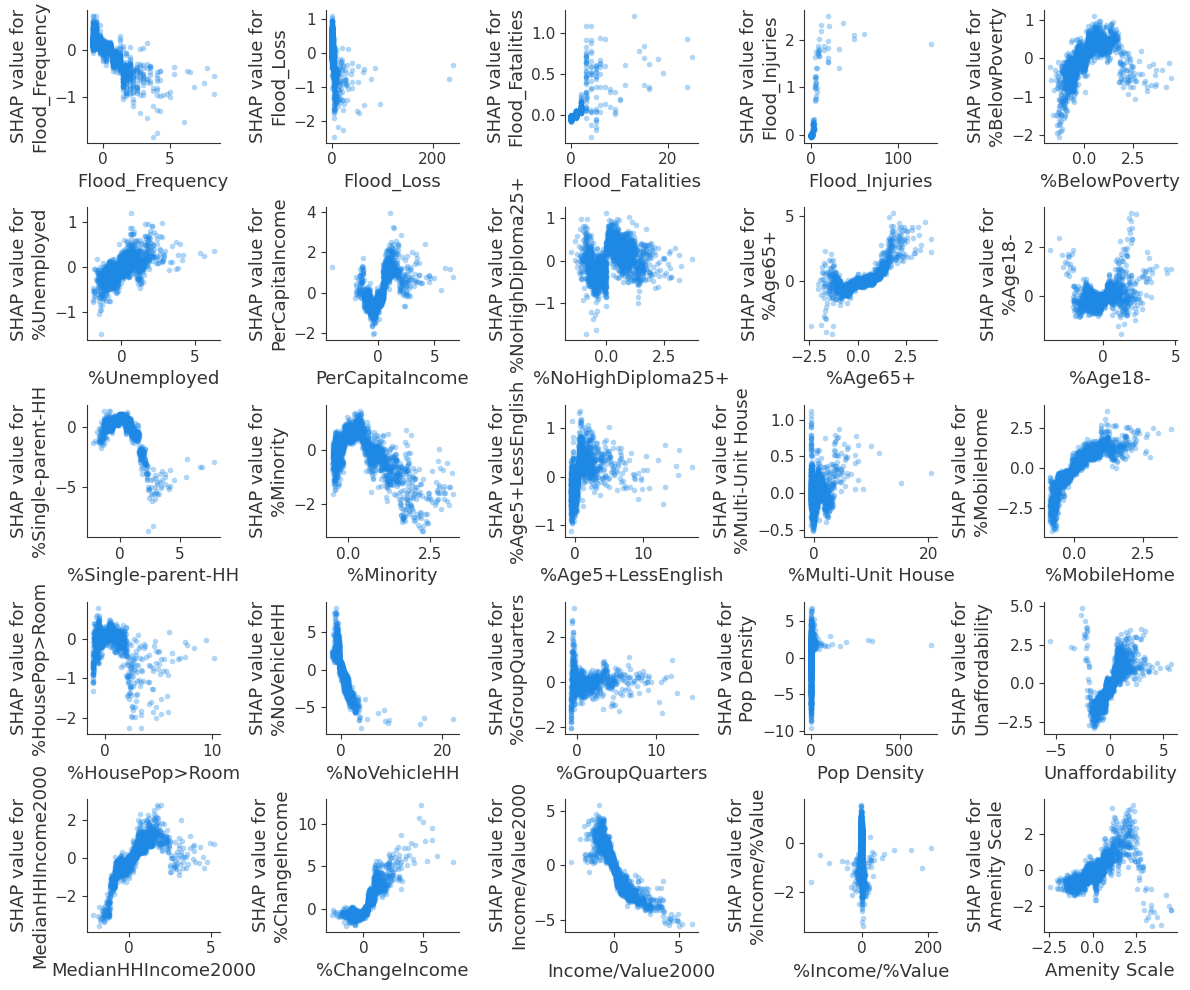

In [18]:
# Get all feature names
all_features = X_train.columns.tolist()

# Grid layout setup
num_features = len(all_features)
cols = 5
rows = (num_features + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(12,10))
axes = axes.flatten()

# Loop through each feature to create a SHAP dependence plot in its subplot
for i, feature in enumerate(all_features):
    shap.dependence_plot(
        feature,
        shap_values.values,
        X_train,
        ax=axes[i],
        interaction_index=None,  # Ensures no color gradient (blue dots only)
        show=False,
        alpha=0.35
    )
#     axes[i].set_title(f"{feature}", fontsize=10)
# Hide any unused subplot areas
for j in range(len(all_features), len(axes)):
    axes[j].axis("off")

# Final layout and output
plt.tight_layout()
plt.show()

## Wildfire

In [19]:
# Load your hurricane regression data
data_path = "F:/LongMig2025/data/"
df = pd.read_csv(data_path+"Regression/Wildfire_Regression_data.csv")  # Adjust path if needed

In [20]:
# Prepare features and target
X = df.drop(columns=["Unnamed: 0", "FIPS", "NMR"])
y = df["NMR"]

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and run FLAML
automl = AutoML()
automl.fit(
    X_train=X_train,
    y_train=y_train,
    task="regression",
    time_budget=600,
    metric="rmse",
    estimator_list=[
        "xgboost", "xgb_limitdepth", "rf", "extra_tree", "lgbm", "histgb", "catboost"
    ],
    log_type="all",
    log_file_name=data_path + "Regression/flaml_log_wildfire.txt"    
)

[flaml.automl.logger: 05-20 03:38:12] {1728} INFO - task = regression
[flaml.automl.logger: 05-20 03:38:12] {1739} INFO - Evaluation method: cv
[flaml.automl.logger: 05-20 03:38:12] {1838} INFO - Minimizing error metric: rmse
[flaml.automl.logger: 05-20 03:38:12] {1955} INFO - List of ML learners in AutoML Run: ['xgboost', 'xgb_limitdepth', 'rf', 'extra_tree', 'lgbm', 'histgb', 'catboost']
[flaml.automl.logger: 05-20 03:38:12] {2258} INFO - iteration 0, current learner xgboost
[flaml.automl.logger: 05-20 03:38:12] {2393} INFO - Estimated sufficient time budget=3252s. Estimated necessary time budget=18s.
[flaml.automl.logger: 05-20 03:38:12] {2442} INFO -  at 0.4s,	estimator xgboost's best error=8.2479,	best estimator xgboost's best error=8.2479
[flaml.automl.logger: 05-20 03:38:12] {2258} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 05-20 03:38:12] {2442} INFO -  at 0.5s,	estimator lgbm's best error=8.2325,	best estimator lgbm's best error=8.2325
[flaml.automl.logger:

[flaml.automl.logger: 05-20 03:38:20] {2258} INFO - iteration 34, current learner histgb
[flaml.automl.logger: 05-20 03:38:21] {2442} INFO -  at 8.8s,	estimator histgb's best error=5.9668,	best estimator histgb's best error=5.9668
[flaml.automl.logger: 05-20 03:38:21] {2258} INFO - iteration 35, current learner extra_tree
[flaml.automl.logger: 05-20 03:38:21] {2442} INFO -  at 9.2s,	estimator extra_tree's best error=7.3915,	best estimator histgb's best error=5.9668
[flaml.automl.logger: 05-20 03:38:21] {2258} INFO - iteration 36, current learner lgbm
[flaml.automl.logger: 05-20 03:38:22] {2442} INFO -  at 10.0s,	estimator lgbm's best error=6.0082,	best estimator histgb's best error=5.9668
[flaml.automl.logger: 05-20 03:38:22] {2258} INFO - iteration 37, current learner histgb
[flaml.automl.logger: 05-20 03:38:22] {2442} INFO -  at 10.1s,	estimator histgb's best error=5.9668,	best estimator histgb's best error=5.9668
[flaml.automl.logger: 05-20 03:38:22] {2258} INFO - iteration 38, curr

[flaml.automl.logger: 05-20 03:38:35] {2442} INFO -  at 23.2s,	estimator xgboost's best error=6.2875,	best estimator histgb's best error=5.9197
[flaml.automl.logger: 05-20 03:38:35] {2258} INFO - iteration 70, current learner histgb
[flaml.automl.logger: 05-20 03:38:35] {2442} INFO -  at 23.5s,	estimator histgb's best error=5.9197,	best estimator histgb's best error=5.9197
[flaml.automl.logger: 05-20 03:38:35] {2258} INFO - iteration 71, current learner histgb
[flaml.automl.logger: 05-20 03:38:35] {2442} INFO -  at 23.7s,	estimator histgb's best error=5.9197,	best estimator histgb's best error=5.9197
[flaml.automl.logger: 05-20 03:38:35] {2258} INFO - iteration 72, current learner histgb
[flaml.automl.logger: 05-20 03:38:35] {2442} INFO -  at 23.8s,	estimator histgb's best error=5.9197,	best estimator histgb's best error=5.9197
[flaml.automl.logger: 05-20 03:38:35] {2258} INFO - iteration 73, current learner histgb
[flaml.automl.logger: 05-20 03:38:36] {2442} INFO -  at 24.1s,	estimato

[flaml.automl.logger: 05-20 03:38:56] {2258} INFO - iteration 105, current learner histgb
[flaml.automl.logger: 05-20 03:38:56] {2442} INFO -  at 44.8s,	estimator histgb's best error=5.8305,	best estimator histgb's best error=5.8305
[flaml.automl.logger: 05-20 03:38:56] {2258} INFO - iteration 106, current learner lgbm
[flaml.automl.logger: 05-20 03:38:57] {2442} INFO -  at 45.2s,	estimator lgbm's best error=6.0082,	best estimator histgb's best error=5.8305
[flaml.automl.logger: 05-20 03:38:57] {2258} INFO - iteration 107, current learner histgb
[flaml.automl.logger: 05-20 03:38:58] {2442} INFO -  at 46.3s,	estimator histgb's best error=5.8305,	best estimator histgb's best error=5.8305
[flaml.automl.logger: 05-20 03:38:58] {2258} INFO - iteration 108, current learner histgb
[flaml.automl.logger: 05-20 03:38:58] {2442} INFO -  at 46.7s,	estimator histgb's best error=5.8305,	best estimator histgb's best error=5.8305
[flaml.automl.logger: 05-20 03:38:58] {2258} INFO - iteration 109, curre

[flaml.automl.logger: 05-20 03:39:20] {2258} INFO - iteration 140, current learner xgboost
[flaml.automl.logger: 05-20 03:39:21] {2442} INFO -  at 69.2s,	estimator xgboost's best error=6.1699,	best estimator histgb's best error=5.8305
[flaml.automl.logger: 05-20 03:39:21] {2258} INFO - iteration 141, current learner histgb
[flaml.automl.logger: 05-20 03:39:22] {2442} INFO -  at 70.0s,	estimator histgb's best error=5.7718,	best estimator histgb's best error=5.7718
[flaml.automl.logger: 05-20 03:39:22] {2258} INFO - iteration 142, current learner xgb_limitdepth
[flaml.automl.logger: 05-20 03:39:22] {2442} INFO -  at 70.4s,	estimator xgb_limitdepth's best error=6.2916,	best estimator histgb's best error=5.7718
[flaml.automl.logger: 05-20 03:39:22] {2258} INFO - iteration 143, current learner histgb
[flaml.automl.logger: 05-20 03:39:23] {2442} INFO -  at 71.2s,	estimator histgb's best error=5.7718,	best estimator histgb's best error=5.7718
[flaml.automl.logger: 05-20 03:39:23] {2258} INFO 

...

[flaml.automl.logger: 05-20 03:41:02] {2442} INFO -  at 170.6s,	estimator xgboost's best error=5.9677,	best estimator histgb's best error=5.7414
[flaml.automl.logger: 05-20 03:41:02] {2258} INFO - iteration 246, current learner histgb
[flaml.automl.logger: 05-20 03:41:03] {2442} INFO -  at 171.2s,	estimator histgb's best error=5.7414,	best estimator histgb's best error=5.7414
[flaml.automl.logger: 05-20 03:41:03] {2258} INFO - iteration 247, current learner xgboost
[flaml.automl.logger: 05-20 03:41:06] {2442} INFO -  at 174.1s,	estimator xgboost's best error=5.9677,	best estimator histgb's best error=5.7414
[flaml.automl.logger: 05-20 03:41:06] {2258} INFO - iteration 248, current learner histgb
[flaml.automl.logger: 05-20 03:41:07] {2442} INFO -  at 174.9s,	estimator histgb's best error=5.7414,	best estimator histgb's best error=5.7414
[flaml.automl.logger: 05-20 03:41:07] {2258} INFO - iteration 249, current learner rf
[flaml.automl.logger: 05-20 03:41:10] {2442} INFO -  at 177.8s,	e

[flaml.automl.logger: 05-20 03:42:10] {2258} INFO - iteration 281, current learner histgb
[flaml.automl.logger: 05-20 03:42:11] {2442} INFO -  at 239.4s,	estimator histgb's best error=5.7414,	best estimator histgb's best error=5.7414
[flaml.automl.logger: 05-20 03:42:11] {2258} INFO - iteration 282, current learner histgb
[flaml.automl.logger: 05-20 03:42:12] {2442} INFO -  at 240.7s,	estimator histgb's best error=5.7414,	best estimator histgb's best error=5.7414
[flaml.automl.logger: 05-20 03:42:12] {2258} INFO - iteration 283, current learner xgb_limitdepth
[flaml.automl.logger: 05-20 03:42:13] {2442} INFO -  at 241.0s,	estimator xgb_limitdepth's best error=6.2916,	best estimator histgb's best error=5.7414
[flaml.automl.logger: 05-20 03:42:13] {2258} INFO - iteration 284, current learner rf
[flaml.automl.logger: 05-20 03:42:16] {2442} INFO -  at 243.9s,	estimator rf's best error=6.0517,	best estimator histgb's best error=5.7414
[flaml.automl.logger: 05-20 03:42:16] {2258} INFO - iter

[flaml.automl.logger: 05-20 03:43:02] {2442} INFO -  at 289.9s,	estimator histgb's best error=5.7414,	best estimator histgb's best error=5.7414
[flaml.automl.logger: 05-20 03:43:02] {2258} INFO - iteration 316, current learner xgb_limitdepth
[flaml.automl.logger: 05-20 03:43:05] {2442} INFO -  at 292.9s,	estimator xgb_limitdepth's best error=5.9573,	best estimator histgb's best error=5.7414
[flaml.automl.logger: 05-20 03:43:05] {2258} INFO - iteration 317, current learner histgb
[flaml.automl.logger: 05-20 03:43:05] {2442} INFO -  at 293.6s,	estimator histgb's best error=5.7414,	best estimator histgb's best error=5.7414
[flaml.automl.logger: 05-20 03:43:05] {2258} INFO - iteration 318, current learner histgb
[flaml.automl.logger: 05-20 03:43:06] {2442} INFO -  at 294.5s,	estimator histgb's best error=5.7414,	best estimator histgb's best error=5.7414
[flaml.automl.logger: 05-20 03:43:06] {2258} INFO - iteration 319, current learner xgb_limitdepth
[flaml.automl.logger: 05-20 03:43:10] {2

[flaml.automl.logger: 05-20 03:44:24] {2258} INFO - iteration 350, current learner catboost
[flaml.automl.logger: 05-20 03:44:32] {2442} INFO -  at 380.6s,	estimator catboost's best error=6.0501,	best estimator histgb's best error=5.7414
[flaml.automl.logger: 05-20 03:44:32] {2258} INFO - iteration 351, current learner xgb_limitdepth
[flaml.automl.logger: 05-20 03:44:39] {2442} INFO -  at 387.4s,	estimator xgb_limitdepth's best error=5.7891,	best estimator histgb's best error=5.7414
[flaml.automl.logger: 05-20 03:44:39] {2258} INFO - iteration 352, current learner xgb_limitdepth
[flaml.automl.logger: 05-20 03:44:43] {2442} INFO -  at 391.3s,	estimator xgb_limitdepth's best error=5.7891,	best estimator histgb's best error=5.7414
[flaml.automl.logger: 05-20 03:44:43] {2258} INFO - iteration 353, current learner xgb_limitdepth
[flaml.automl.logger: 05-20 03:44:52] {2442} INFO -  at 400.7s,	estimator xgb_limitdepth's best error=5.7891,	best estimator histgb's best error=5.7414
[flaml.autom

[flaml.automl.logger: 05-20 03:47:01] {2442} INFO -  at 528.8s,	estimator histgb's best error=5.7414,	best estimator histgb's best error=5.7414
[flaml.automl.logger: 05-20 03:47:01] {2258} INFO - iteration 385, current learner histgb
[flaml.automl.logger: 05-20 03:47:01] {2442} INFO -  at 529.4s,	estimator histgb's best error=5.7414,	best estimator histgb's best error=5.7414
[flaml.automl.logger: 05-20 03:47:01] {2258} INFO - iteration 386, current learner xgb_limitdepth
[flaml.automl.logger: 05-20 03:47:09] {2442} INFO -  at 536.8s,	estimator xgb_limitdepth's best error=5.7891,	best estimator histgb's best error=5.7414
[flaml.automl.logger: 05-20 03:47:09] {2258} INFO - iteration 387, current learner lgbm
[flaml.automl.logger: 05-20 03:47:14] {2442} INFO -  at 542.4s,	estimator lgbm's best error=5.9309,	best estimator histgb's best error=5.7414
[flaml.automl.logger: 05-20 03:47:14] {2258} INFO - iteration 388, current learner histgb
[flaml.automl.logger: 05-20 03:47:15] {2442} INFO - 

In [21]:
print("Best model:", automl.model.estimator)

Best model: HistGradientBoostingRegressor(l2_regularization=0.7190067512858858,
                              learning_rate=0.03681726276670475, max_iter=435,
                              max_leaf_nodes=4, min_samples_leaf=12,
                              random_state=24092023)


In [22]:
log_path = data_path + "Regression/flaml_log_wildfire.txt"  

entries = []

with open(log_path, "r") as f:
    for line in f:
        try:
            record = json.loads(line)
            learner = record.get("learner")
            val_loss = record.get("validation_loss")
            config = record.get("config")
            if learner and val_loss:
                entries.append({
                    "learner": learner,
                    "validation_loss": val_loss,
                    "config": config
                })
        except json.JSONDecodeError:
            continue

In [23]:
log_df = pd.DataFrame(entries)
log_df = log_df.sort_values("validation_loss").drop_duplicates("learner").head(10).reset_index(drop=True)
print(log_df[["learner", "validation_loss"]])

          learner  validation_loss
0          histgb         5.738278
1  xgb_limitdepth         5.776351
2            lgbm         5.930891
3         xgboost         5.952360
4              rf         6.022770
5        catboost         6.050059
6      extra_tree         6.346903


In [24]:
y_pred = automl.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
me = np.mean(y_test - y_pred)
r2 = r2_score(y_test, y_pred)
print("✅ Best Model Performance on Test Set")
print(f"Best Model: {automl.best_estimator}")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"ME (Mean Error): {me:.4f}")


✅ Best Model Performance on Test Set
Best Model: histgb
R² Score: 0.6027
RMSE: 6.2917
MAE: 4.5098
ME (Mean Error): 0.6309


PermutationExplainer explainer: 437it [03:47,  1.84it/s]                                                               


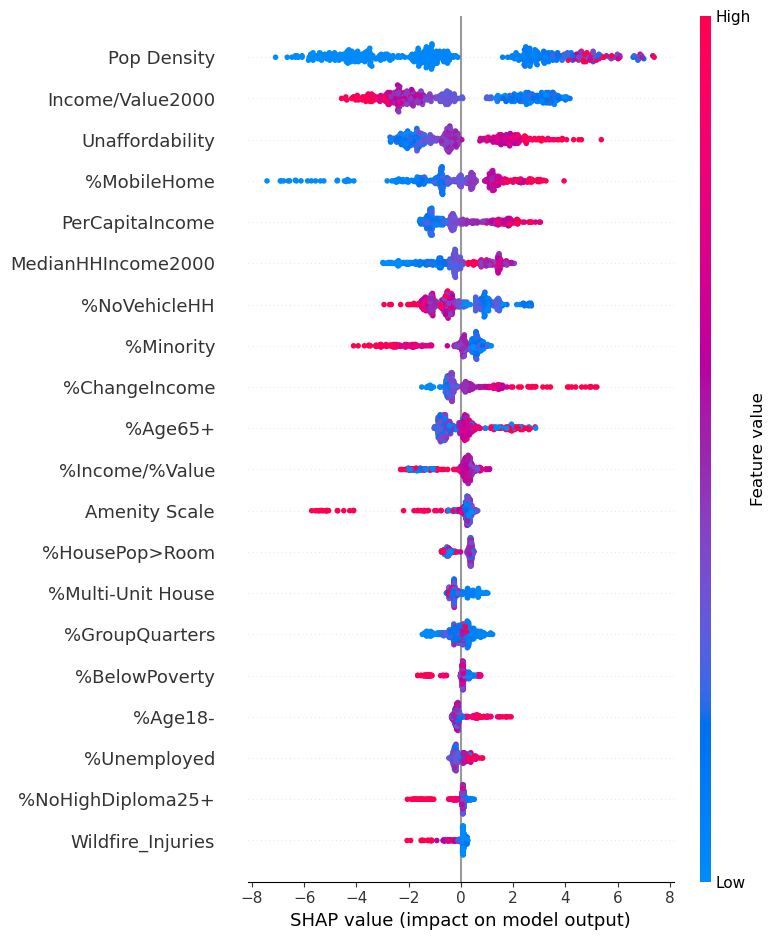

In [25]:
explainer = shap.Explainer(automl.model.predict, X_train)
shap_values = explainer(X_train)
shap.summary_plot(shap_values, X_train)

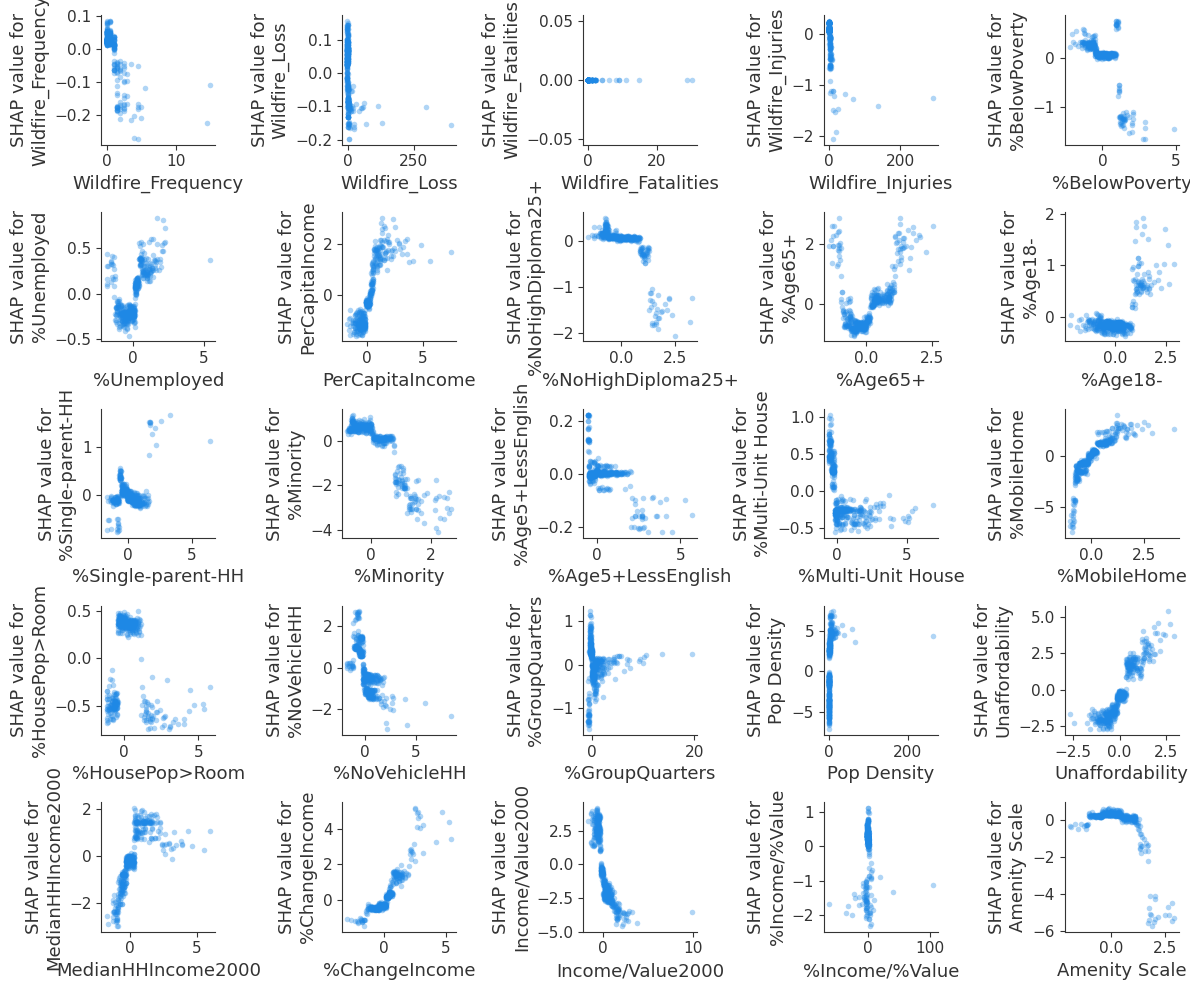

In [26]:
# Get all feature names
all_features = X_train.columns.tolist()

# Grid layout setup
num_features = len(all_features)
cols = 5
rows = (num_features + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(12,10))
axes = axes.flatten()

# Loop through each feature to create a SHAP dependence plot in its subplot
for i, feature in enumerate(all_features):
    shap.dependence_plot(
        feature,
        shap_values.values,
        X_train,
        ax=axes[i],
        interaction_index=None,  # Ensures no color gradient (blue dots only)
        show=False,
        alpha=0.35
    )
#     axes[i].set_title(f"{feature}", fontsize=10)
# Hide any unused subplot areas
for j in range(len(all_features), len(axes)):
    axes[j].axis("off")

# Final layout and output
plt.tight_layout()
plt.show()

## Tornado

In [27]:
# Load your hurricane regression data
data_path = "F:/LongMig2025/data/"
df = pd.read_csv(data_path+"Regression/Tornado_Regression_data.csv")  # Adjust path if needed

In [28]:
# Prepare features and target
X = df.drop(columns=["Unnamed: 0", "FIPS", "NMR"])
y = df["NMR"]

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and run FLAML
automl = AutoML()
automl.fit(
    X_train=X_train,
    y_train=y_train,
    task="regression",
    time_budget=600,
    metric="rmse",
    estimator_list=[
        "xgboost", "xgb_limitdepth", "rf", "extra_tree", "lgbm", "histgb", "catboost"
    ],
    log_type="all",
    log_file_name=data_path + "Regression/flaml_log_tornado.txt"    
)

[flaml.automl.logger: 05-20 03:52:01] {1728} INFO - task = regression
[flaml.automl.logger: 05-20 03:52:01] {1739} INFO - Evaluation method: cv
[flaml.automl.logger: 05-20 03:52:01] {1838} INFO - Minimizing error metric: rmse
[flaml.automl.logger: 05-20 03:52:01] {1955} INFO - List of ML learners in AutoML Run: ['xgboost', 'xgb_limitdepth', 'rf', 'extra_tree', 'lgbm', 'histgb', 'catboost']
[flaml.automl.logger: 05-20 03:52:01] {2258} INFO - iteration 0, current learner xgboost
[flaml.automl.logger: 05-20 03:52:01] {2393} INFO - Estimated sufficient time budget=3442s. Estimated necessary time budget=19s.
[flaml.automl.logger: 05-20 03:52:01] {2442} INFO -  at 0.4s,	estimator xgboost's best error=7.3648,	best estimator xgboost's best error=7.3648
[flaml.automl.logger: 05-20 03:52:01] {2258} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 05-20 03:52:02] {2442} INFO -  at 0.6s,	estimator lgbm's best error=7.3823,	best estimator xgboost's best error=7.3648
[flaml.automl.logg

[flaml.automl.logger: 05-20 03:52:13] {2258} INFO - iteration 34, current learner histgb
[flaml.automl.logger: 05-20 03:52:14] {2442} INFO -  at 12.5s,	estimator histgb's best error=4.9378,	best estimator histgb's best error=4.9378
[flaml.automl.logger: 05-20 03:52:14] {2258} INFO - iteration 35, current learner extra_tree
[flaml.automl.logger: 05-20 03:52:14] {2442} INFO -  at 13.3s,	estimator extra_tree's best error=5.7610,	best estimator histgb's best error=4.9378
[flaml.automl.logger: 05-20 03:52:14] {2258} INFO - iteration 36, current learner histgb
[flaml.automl.logger: 05-20 03:52:15] {2442} INFO -  at 14.1s,	estimator histgb's best error=4.8209,	best estimator histgb's best error=4.8209
[flaml.automl.logger: 05-20 03:52:15] {2258} INFO - iteration 37, current learner histgb
[flaml.automl.logger: 05-20 03:52:17] {2442} INFO -  at 16.0s,	estimator histgb's best error=4.7523,	best estimator histgb's best error=4.7523
[flaml.automl.logger: 05-20 03:52:17] {2258} INFO - iteration 38

[flaml.automl.logger: 05-20 03:53:26] {2442} INFO -  at 85.1s,	estimator histgb's best error=4.7237,	best estimator histgb's best error=4.7237
[flaml.automl.logger: 05-20 03:53:26] {2258} INFO - iteration 70, current learner xgboost
[flaml.automl.logger: 05-20 03:53:27] {2442} INFO -  at 85.5s,	estimator xgboost's best error=6.1348,	best estimator histgb's best error=4.7237
[flaml.automl.logger: 05-20 03:53:27] {2258} INFO - iteration 71, current learner histgb
[flaml.automl.logger: 05-20 03:53:31] {2442} INFO -  at 90.2s,	estimator histgb's best error=4.7037,	best estimator histgb's best error=4.7037
[flaml.automl.logger: 05-20 03:53:31] {2258} INFO - iteration 72, current learner xgb_limitdepth
[flaml.automl.logger: 05-20 03:53:32] {2442} INFO -  at 90.8s,	estimator xgb_limitdepth's best error=5.1192,	best estimator histgb's best error=4.7037
[flaml.automl.logger: 05-20 03:53:32] {2258} INFO - iteration 73, current learner xgb_limitdepth
[flaml.automl.logger: 05-20 03:53:33] {2442} I

[flaml.automl.logger: 05-20 03:55:24] {2442} INFO -  at 202.4s,	estimator histgb's best error=4.6861,	best estimator histgb's best error=4.6861
[flaml.automl.logger: 05-20 03:55:24] {2258} INFO - iteration 104, current learner extra_tree
[flaml.automl.logger: 05-20 03:55:25] {2442} INFO -  at 204.4s,	estimator extra_tree's best error=4.8729,	best estimator histgb's best error=4.6861
[flaml.automl.logger: 05-20 03:55:25] {2258} INFO - iteration 105, current learner xgboost
[flaml.automl.logger: 05-20 03:55:26] {2442} INFO -  at 204.7s,	estimator xgboost's best error=6.1348,	best estimator histgb's best error=4.6861
[flaml.automl.logger: 05-20 03:55:26] {2258} INFO - iteration 106, current learner extra_tree
[flaml.automl.logger: 05-20 03:55:30] {2442} INFO -  at 208.4s,	estimator extra_tree's best error=4.8729,	best estimator histgb's best error=4.6861
[flaml.automl.logger: 05-20 03:55:30] {2258} INFO - iteration 107, current learner xgb_limitdepth
[flaml.automl.logger: 05-20 03:55:31] 

[flaml.automl.logger: 05-20 03:58:04] {2258} INFO - iteration 138, current learner catboost
[flaml.automl.logger: 05-20 03:58:13] {2442} INFO -  at 371.8s,	estimator catboost's best error=4.7113,	best estimator histgb's best error=4.6515
[flaml.automl.logger: 05-20 03:58:13] {2258} INFO - iteration 139, current learner extra_tree
[flaml.automl.logger: 05-20 03:58:16] {2442} INFO -  at 374.4s,	estimator extra_tree's best error=4.8650,	best estimator histgb's best error=4.6515
[flaml.automl.logger: 05-20 03:58:16] {2258} INFO - iteration 140, current learner xgboost
[flaml.automl.logger: 05-20 03:58:17] {2442} INFO -  at 375.6s,	estimator xgboost's best error=5.1351,	best estimator histgb's best error=4.6515
[flaml.automl.logger: 05-20 03:58:17] {2258} INFO - iteration 141, current learner histgb
[flaml.automl.logger: 05-20 03:58:26] {2442} INFO -  at 384.7s,	estimator histgb's best error=4.6515,	best estimator histgb's best error=4.6515
[flaml.automl.logger: 05-20 03:58:26] {2258} INFO 

[flaml.automl.logger: 05-20 04:00:01] {2258} INFO - iteration 173, current learner xgboost
[flaml.automl.logger: 05-20 04:00:06] {2442} INFO -  at 484.5s,	estimator xgboost's best error=4.7906,	best estimator histgb's best error=4.6515
[flaml.automl.logger: 05-20 04:00:06] {2258} INFO - iteration 174, current learner lgbm
[flaml.automl.logger: 05-20 04:00:11] {2442} INFO -  at 489.5s,	estimator lgbm's best error=4.7724,	best estimator histgb's best error=4.6515
[flaml.automl.logger: 05-20 04:00:11] {2258} INFO - iteration 175, current learner lgbm
[flaml.automl.logger: 05-20 04:00:14] {2442} INFO -  at 492.9s,	estimator lgbm's best error=4.7724,	best estimator histgb's best error=4.6515
[flaml.automl.logger: 05-20 04:00:14] {2258} INFO - iteration 176, current learner lgbm
[flaml.automl.logger: 05-20 04:00:18] {2442} INFO -  at 496.6s,	estimator lgbm's best error=4.7724,	best estimator histgb's best error=4.6515
[flaml.automl.logger: 05-20 04:00:18] {2258} INFO - iteration 177, current

In [29]:
print("Best model:", automl.model.estimator)

Best model: HistGradientBoostingRegressor(l2_regularization=0.06224282597597983,
                              learning_rate=0.00926826560541849, max_bins=127,
                              max_iter=1808, max_leaf_nodes=14,
                              min_samples_leaf=6, random_state=24092023)


In [30]:
log_path = data_path + "Regression/flaml_log_tornado.txt"  

entries = []

with open(log_path, "r") as f:
    for line in f:
        try:
            record = json.loads(line)
            learner = record.get("learner")
            val_loss = record.get("validation_loss")
            config = record.get("config")
            if learner and val_loss:
                entries.append({
                    "learner": learner,
                    "validation_loss": val_loss,
                    "config": config
                })
        except json.JSONDecodeError:
            continue

In [31]:
log_df = pd.DataFrame(entries)
log_df = log_df.sort_values("validation_loss").drop_duplicates("learner").head(10).reset_index(drop=True)
print(log_df[["learner", "validation_loss"]])

          learner  validation_loss
0          histgb         4.651463
1        catboost         4.711326
2  xgb_limitdepth         4.764512
3            lgbm         4.768793
4         xgboost         4.790600
5      extra_tree         4.864981
6              rf         4.897512


In [32]:
y_pred = automl.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
me = np.mean(y_test - y_pred)
r2 = r2_score(y_test, y_pred)
print("✅ Best Model Performance on Test Set")
print(f"Best Model: {automl.best_estimator}")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"ME (Mean Error): {me:.4f}")


✅ Best Model Performance on Test Set
Best Model: histgb
R² Score: 0.7133
RMSE: 4.8682
MAE: 3.2160
ME (Mean Error): 0.3964


PermutationExplainer explainer: 1810it [1:12:55,  2.42s/it]                                                            


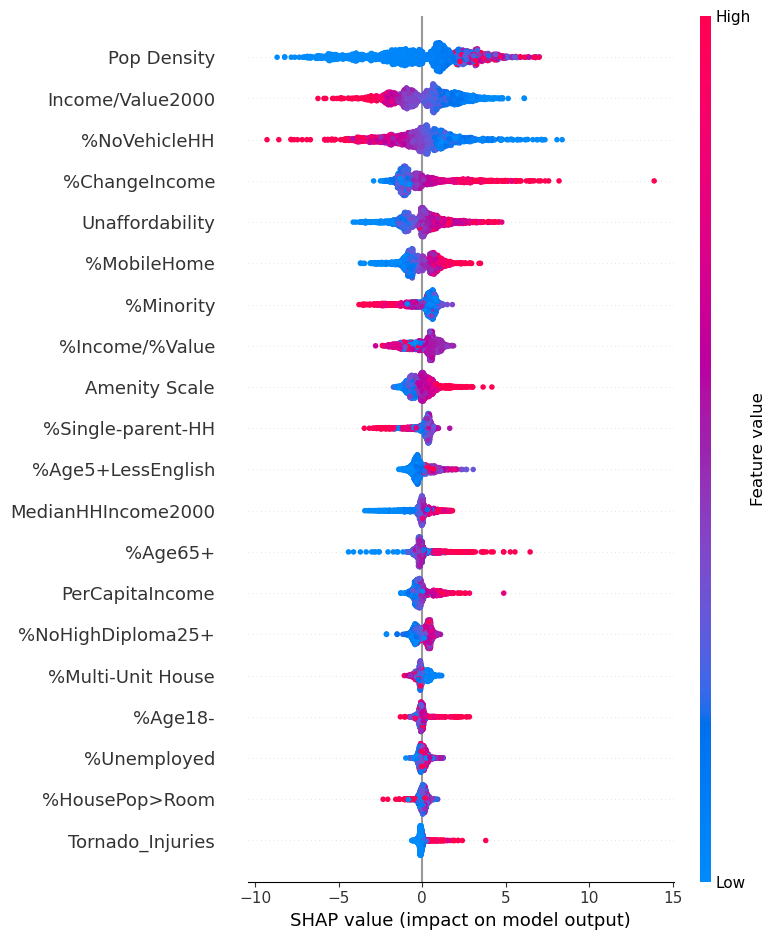

In [33]:
explainer = shap.Explainer(automl.model.predict, X_train)
shap_values = explainer(X_train)
shap.summary_plot(shap_values, X_train)

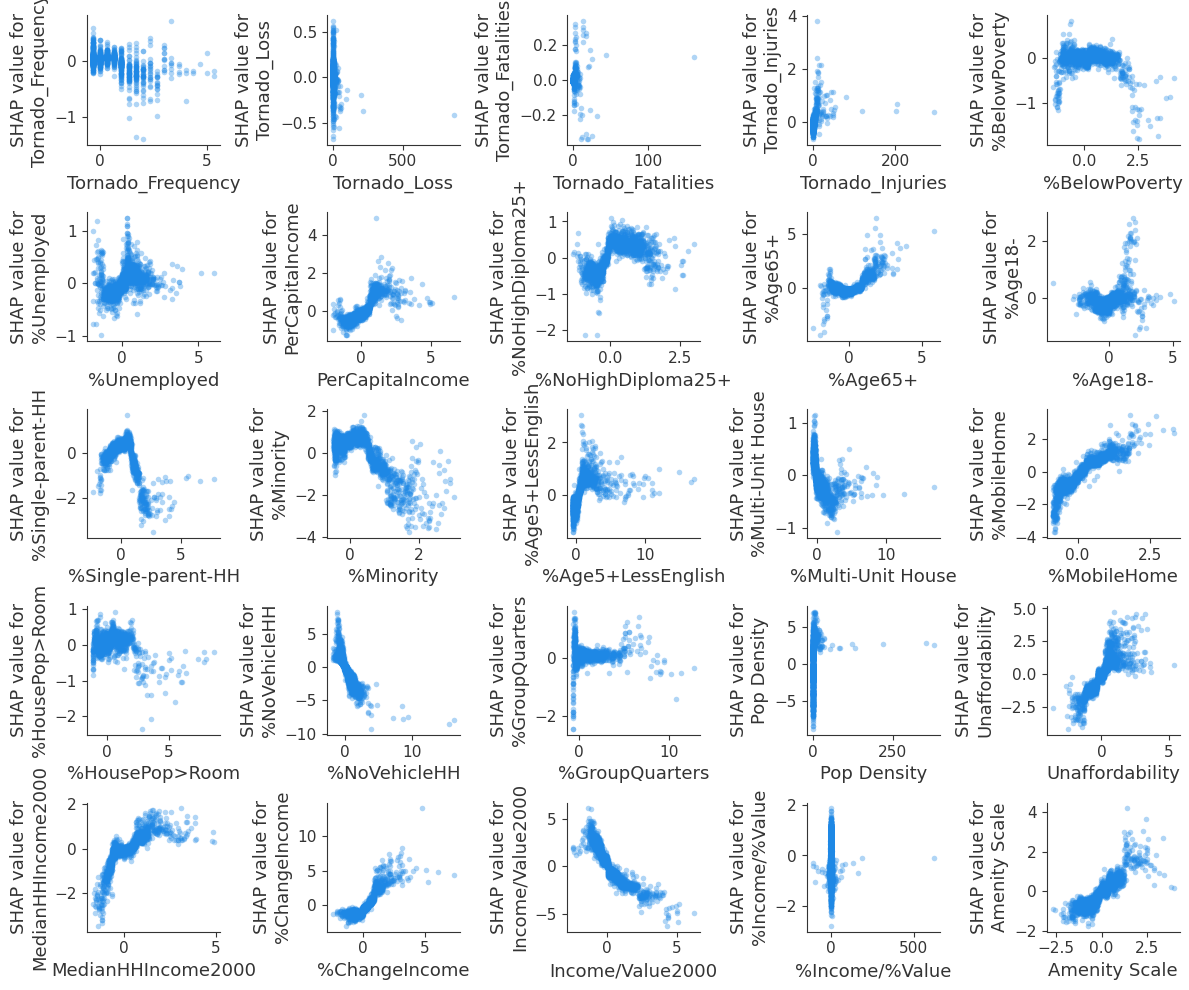

In [34]:
# Get all feature names
all_features = X_train.columns.tolist()

# Grid layout setup
num_features = len(all_features)
cols = 5
rows = (num_features + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(12,10))
axes = axes.flatten()

# Loop through each feature to create a SHAP dependence plot in its subplot
for i, feature in enumerate(all_features):
    shap.dependence_plot(
        feature,
        shap_values.values,
        X_train,
        ax=axes[i],
        interaction_index=None,  # Ensures no color gradient (blue dots only)
        show=False,
        alpha=0.35
    )
#     axes[i].set_title(f"{feature}", fontsize=10)
# Hide any unused subplot areas
for j in range(len(all_features), len(axes)):
    axes[j].axis("off")

# Final layout and output
plt.tight_layout()
plt.show()